# EDA de Ratings (Issue #10)

## Objetivo
Explorar:
- Distribución de ratings
- Promedio por producto
- Cantidad de reseñas por fecha
- Identificación de outliers

## Fuente esperada
CSV en `data/raw/` con columnas mínimas:
- `product_id`
- `rating`
- `review_date`

Nota: Actualmente no hay dataset real de reseñas (Issue #6 en progreso). Este notebook usa data/raw/reviews_sample.csv como dataset de ejemplo para que el análisis y las visualizaciones corran de extremo a extremo.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

def find_project_root(start: Path) -> Path:
    """
    Sube carpetas hasta encontrar una 'señal' de raíz del repo:
    - requirements.txt o
    - .git
    """
    p = start.resolve()
    for _ in range(15):
        if (p / "requirements.txt").exists() or (p / ".git").exists():
            return p
        p = p.parent
    return start.resolve()

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "raw"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("CWD:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)

CWD: c:\Users\danie\Documents\ENDO\MarketPulse\MarketPulseBeauty\notebooks
PROJECT_ROOT: C:\Users\danie\Documents\ENDO\MarketPulse\MarketPulseBeauty
DATA_DIR: C:\Users\danie\Documents\ENDO\MarketPulse\MarketPulseBeauty\data\raw


In [2]:
#crear sample
import random
from datetime import datetime, timedelta

SAMPLE_PATH = DATA_DIR / "reviews_sample.csv"

def find_reviews_csv(data_dir: Path) -> Path | None:
    """
    Busca un CSV de reseñas en data/raw (excluye google_trends).
    Si hay varios, toma el más reciente.
    """
    candidates = []
    for p in data_dir.rglob("*.csv"):
        if "google_trends" in str(p).lower():
            continue
        candidates.append(p)

    if not candidates:
        return None

    candidates.sort(key=lambda x: x.stat().st_mtime, reverse=True)
    return candidates[0]

def create_sample_reviews_csv(path: Path, n_days: int = 14, seed: int = 7) -> None:
    """
    Crea un dataset pequeño pero suficiente para que el EDA produzca:
    - distribución
    - promedio por producto
    - conteo por fecha
    - outliers (algunos ratings bajos)
    """
    random.seed(seed)
    products = ["niacinamida", "acido_hialuronico", "shampoo_sin_sulfatos"]
    start = datetime(2026, 2, 1)

    rows = []
    for d in range(n_days):
        date = (start + timedelta(days=d)).strftime("%Y-%m-%d")
        # 1 a 5 reseñas por día para crear variación
        for _ in range(random.randint(1, 5)):
            p = random.choice(products)
            # sesgo hacia 4-5 pero con algunos 1-2 para outliers
            r = random.choices([1, 2, 3, 4, 5], weights=[6, 10, 18, 33, 33])[0]
            rows.append({"product_id": p, "rating": r, "review_date": date})

    df_sample = pd.DataFrame(rows)
    path.parent.mkdir(parents=True, exist_ok=True)
    df_sample.to_csv(path, index=False, encoding="utf-8")

# 1) intentar dataset real
reviews_path = find_reviews_csv(DATA_DIR)

# 2) si no existe, crear sample y usarlo
if reviews_path is None:
    if not SAMPLE_PATH.exists():
        create_sample_reviews_csv(SAMPLE_PATH, n_days=14, seed=7)
    reviews_path = SAMPLE_PATH

print("Usando archivo:", reviews_path)
print("Es sample:", reviews_path.name == "reviews_sample.csv")

Usando archivo: C:\Users\danie\Documents\ENDO\MarketPulse\MarketPulseBeauty\data\raw\reviews_sample.csv
Es sample: True


In [3]:
#Carga de datos y validacion
df = pd.read_csv(reviews_path)

print("Columnas:", list(df.columns))
print("Filas:", len(df))
display(df.head(10))

required = {"product_id", "rating", "review_date"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}. Necesito {required}.")

Columnas: ['product_id', 'rating', 'review_date']
Filas: 16


,product_id,rating,review_date
0,niacinamida,5,2026-02-01
1,niacinamida,4,2026-02-01
2,niacinamida,3,2026-02-02
3,niacinamida,5,2026-02-05
4,niacinamida,2,2026-02-08
5,acido_hialuronico,4,2026-02-01
6,acido_hialuronico,5,2026-02-03
7,acido_hialuronico,4,2026-02-05
8,acido_hialuronico,1,2026-02-06
9,acido_hialuronico,5,2026-02-08


In [4]:
#limpieza y calidadd
# Convertir tipos
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

# Identificar problemas de calidad
invalid_rating = df[df["rating"].isna() | (df["rating"] < 1) | (df["rating"] > 5)]
invalid_date = df[df["review_date"].isna()]

print("Filas con rating inválido:", len(invalid_rating))
print("Filas con fecha inválida:", len(invalid_date))

# Dataset limpio
clean = df.dropna(subset=["rating", "review_date"]).copy()
clean = clean[(clean["rating"] >= 1) & (clean["rating"] <= 5)]
clean["date"] = clean["review_date"].dt.date

print("Filas limpias:", len(clean))
display(clean.head(10))

Filas con rating inválido: 0
Filas con fecha inválida: 0
Filas limpias: 16


,product_id,rating,review_date,date
0,niacinamida,5,2026-02-01,2026-02-01
1,niacinamida,4,2026-02-01,2026-02-01
2,niacinamida,3,2026-02-02,2026-02-02
3,niacinamida,5,2026-02-05,2026-02-05
4,niacinamida,2,2026-02-08,2026-02-08
5,acido_hialuronico,4,2026-02-01,2026-02-01
6,acido_hialuronico,5,2026-02-03,2026-02-03
7,acido_hialuronico,4,2026-02-05,2026-02-05
8,acido_hialuronico,1,2026-02-06,2026-02-06
9,acido_hialuronico,5,2026-02-08,2026-02-08


## 1) Distribución de ratings
Se analiza cuántas reseñas hay por cada valor de rating (1 a 5).

,count
rating,
1,2
2,2
3,1
4,5
5,6


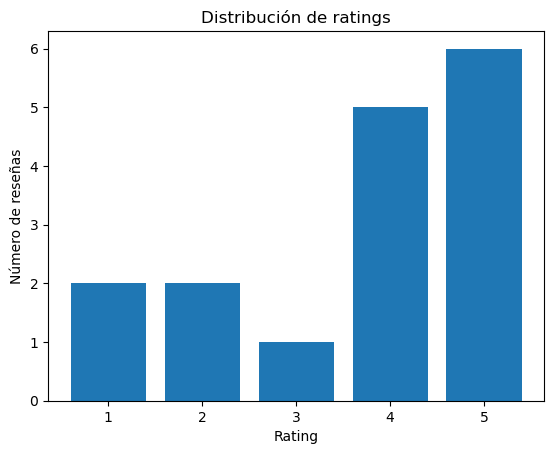

,count,pct_%
rating,,
1,2,12.5
2,2,12.5
3,1,6.2
4,5,31.2
5,6,37.5


In [5]:
#plot dstribucion
counts = clean["rating"].value_counts().sort_index()
display(counts.to_frame("count"))

plt.figure()
plt.bar(counts.index.astype(int).astype(str), counts.values)
plt.title("Distribución de ratings")
plt.xlabel("Rating")
plt.ylabel("Número de reseñas")
plt.show()

# Proporciones
pct = (counts / counts.sum() * 100).round(1)
display(pd.DataFrame({"count": counts, "pct_%": pct}))

## 2) Promedio por producto
Se calcula:
- promedio de rating por `product_id`
- número de reseñas por producto

,avg_rating,n_reviews,std_rating
product_id,,,
acido_hialuronico,3.8,5,1.643168
niacinamida,3.8,5,1.303840
shampoo_sin_sulfatos,3.5,6,1.643168


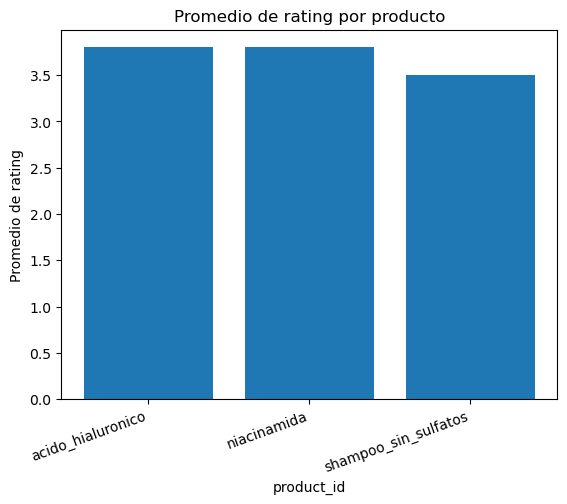

In [6]:
#tabla y plot por producto
by_product = clean.groupby("product_id").agg(
    avg_rating=("rating", "mean"),
    n_reviews=("rating", "count"),
    std_rating=("rating", "std")
).sort_values(["avg_rating", "n_reviews"], ascending=[False, False])

display(by_product)

plt.figure()
plt.bar(by_product.index.astype(str), by_product["avg_rating"])
plt.title("Promedio de rating por producto")
plt.xlabel("product_id")
plt.ylabel("Promedio de rating")
plt.xticks(rotation=20, ha="right")
plt.show()

## 3) Cantidad de reseñas por fecha
Se agrupan reseñas por día para detectar tendencias y picos (días con mucha actividad).

,reviews_count
date,
2026-02-01,5
2026-02-02,1
2026-02-03,1
2026-02-04,1
2026-02-05,2
2026-02-06,1
2026-02-07,1
2026-02-08,4


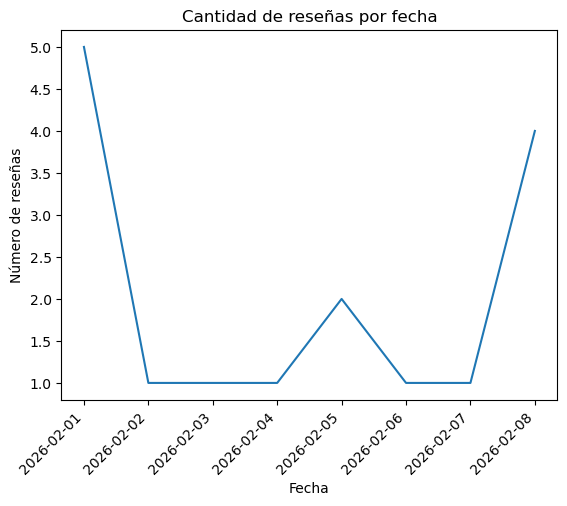

In [7]:
#tabla y plot por fecha 
by_date = clean.groupby("date").size().sort_index()
display(by_date.to_frame("reviews_count").head(15))

plt.figure()
plt.plot(by_date.index.astype(str), by_date.values)
plt.title("Cantidad de reseñas por fecha")
plt.xlabel("Fecha")
plt.ylabel("Número de reseñas")
plt.xticks(rotation=45, ha="right")
plt.show()

## 4) Identificación de outliers

Se reportan:
1) **Outliers de calidad**: ratings fuera de 1–5 o fechas inválidas.
2) **Outliers por producto**: productos con promedio extremo (IQR sobre promedios).
3) **Outliers por fecha**: días con conteos extremos (IQR sobre conteo diario).

In [8]:
#outliers
# 1) calidad
print("Ejemplos de rating inválido (máx 10):")
display(invalid_rating.head(10))

print("Ejemplos de fecha inválida (máx 10):")
display(invalid_date.head(10))

# 2) outliers por promedio de producto (IQR)
outlier_products = pd.DataFrame()
if len(by_product) >= 4:  # IQR tiene más sentido con varios productos
    avg = by_product["avg_rating"].dropna()
    q1, q3 = avg.quantile(0.25), avg.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_products = by_product[(by_product["avg_rating"] < low) | (by_product["avg_rating"] > high)]

    print(f"Rango IQR (promedio por producto): [{low:.2f}, {high:.2f}]")
else:
    print("No hay suficientes productos para un IQR robusto (se requieren ~4+).")

print("Productos outliers por promedio:")
display(outlier_products if not outlier_products.empty else pd.DataFrame({"info": ["Sin outliers detectados por IQR (o pocos datos)"]}))

# 3) outliers por fecha (IQR sobre conteos diarios)
outlier_days = pd.Series(dtype=int)
if len(by_date) >= 7:  # para tener algo de distribución temporal
    q1d, q3d = by_date.quantile(0.25), by_date.quantile(0.75)
    iqrd = q3d - q1d
    lowd, highd = q1d - 1.5 * iqrd, q3d + 1.5 * iqrd
    outlier_days = by_date[(by_date < lowd) | (by_date > highd)]

    print(f"Rango IQR (conteo diario): [{lowd:.2f}, {highd:.2f}]")
else:
    print("No hay suficientes días para un IQR temporal robusto (se requieren ~7+).")

print("Días outliers por volumen de reseñas:")
display(outlier_days.to_frame("reviews_count") if len(outlier_days) else pd.DataFrame({"info": ["Sin outliers detectados por IQR (o pocos datos)"]}))

Ejemplos de rating inválido (máx 10):


,product_id,rating,review_date


Ejemplos de fecha inválida (máx 10):


,product_id,rating,review_date


No hay suficientes productos para un IQR robusto (se requieren ~4+).
Productos outliers por promedio:


,info
0,Sin outliers detectados por IQR (o pocos datos)


Rango IQR (conteo diario): [-1.25, 4.75]
Días outliers por volumen de reseñas:


,reviews_count
date,
2026-02-01,5


In [9]:
# Resumen numérico útil para "hallazgos preliminares"
summary = {}

summary["dataset"] = reviews_path.name
summary["n_rows_total"] = int(len(df))
summary["n_rows_clean"] = int(len(clean))
summary["invalid_rating_rows"] = int(len(invalid_rating))
summary["invalid_date_rows"] = int(len(invalid_date))

# distribución top
dist = (clean["rating"].value_counts(normalize=True).sort_index() * 100).round(1)
summary["rating_distribution_pct"] = dist.to_dict()

# mejor/peor producto (si hay datos)
if len(by_product):
    best = by_product.iloc[0]
    worst = by_product.iloc[-1]
    summary["best_product"] = {"product_id": str(by_product.index[0]), "avg_rating": float(best["avg_rating"]), "n_reviews": int(best["n_reviews"])}
    summary["worst_product"] = {"product_id": str(by_product.index[-1]), "avg_rating": float(worst["avg_rating"]), "n_reviews": int(worst["n_reviews"])}

# pico por fecha
if len(by_date):
    peak_date = by_date.idxmax()
    summary["peak_day"] = {"date": str(peak_date), "reviews_count": int(by_date.max())}

summary

{'dataset': 'reviews_sample.csv',
 'n_rows_total': 16,
 'n_rows_clean': 16,
 'invalid_rating_rows': 0,
 'invalid_date_rows': 0,
 'rating_distribution_pct': {1: 12.5, 2: 12.5, 3: 6.2, 4: 31.2, 5: 37.5},
 'best_product': {'product_id': 'acido_hialuronico',
  'avg_rating': 3.8,
  'n_reviews': 5},
 'worst_product': {'product_id': 'shampoo_sin_sulfatos',
  'avg_rating': 3.5,
  'n_reviews': 6},
 'peak_day': {'date': '2026-02-01', 'reviews_count': 5}}

## Hallazgos preliminares (auto-resumen + texto)

En esta sección se resumen hallazgos basados en:
- distribución de ratings,
- promedios por producto,
- picos por fecha,
- outliers de calidad y estadísticos.

> Nota: Si el dataset usado es `reviews_sample.csv`, estos hallazgos son demostrativos y deben revalidarse cuando se integre el dataset real (Issue #6).



- **Distribución:** se observa el comportamiento de los ratings (porcentaje por valor 1–5).  
- **Promedio por producto:** se identifican diferencias en el promedio y el número de reseñas por `product_id`.  
- **Temporalidad:** el conteo por fecha permite detectar picos de actividad (días con más reseñas).  
- **Outliers:** se reportan registros inválidos (si existen) y se evalúan posibles outliers estadísticos por producto y por fecha (IQR).

Cuando el dataset real de reseñas sea integrado (Issue #6), este análisis debe re-ejecutarse para validar los hallazgos con datos reales.